✅ Data loaded successfully.
🔎 Found 1369 null values. Filling them using forward fill.

--- Descriptive Statistics for Daily Average CO ---
count    181.000000
mean       0.047621
std        0.014121
min        0.028226
25%        0.038021
50%        0.041982
75%        0.054053
max        0.098300
Name: CO, dtype: float64
--------------------------------------------------



/var/folders/qm/p5vffjb56gvb80sz8bwjxy780000gn/T/ipykernel_11128/356523136.py:30: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


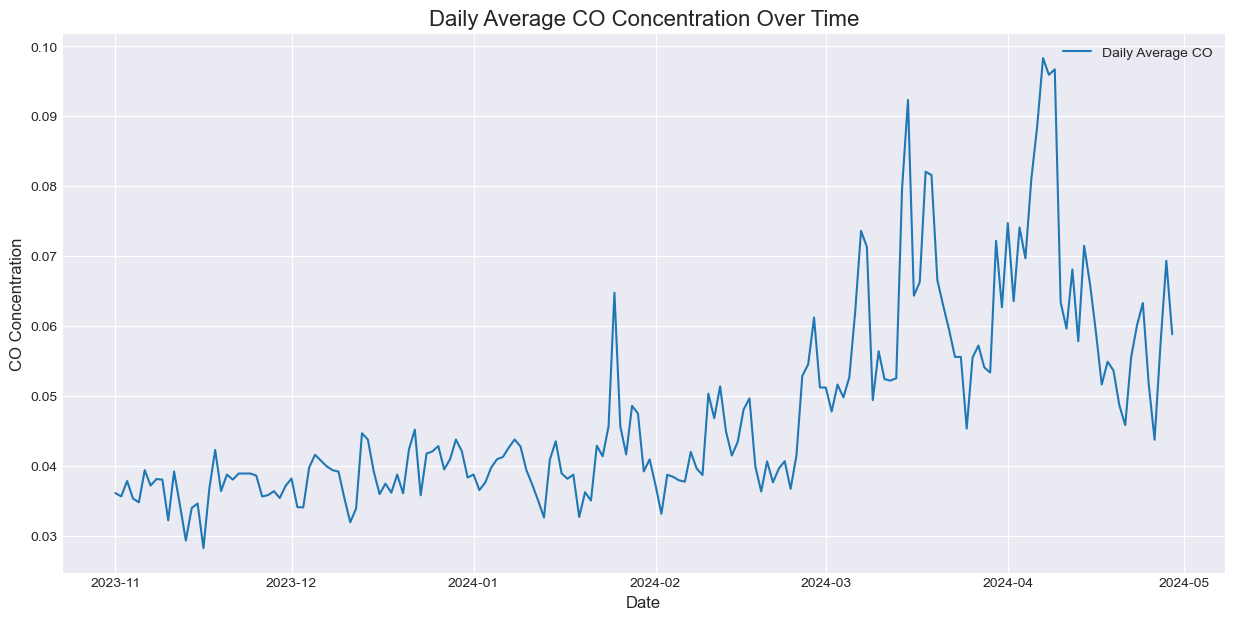

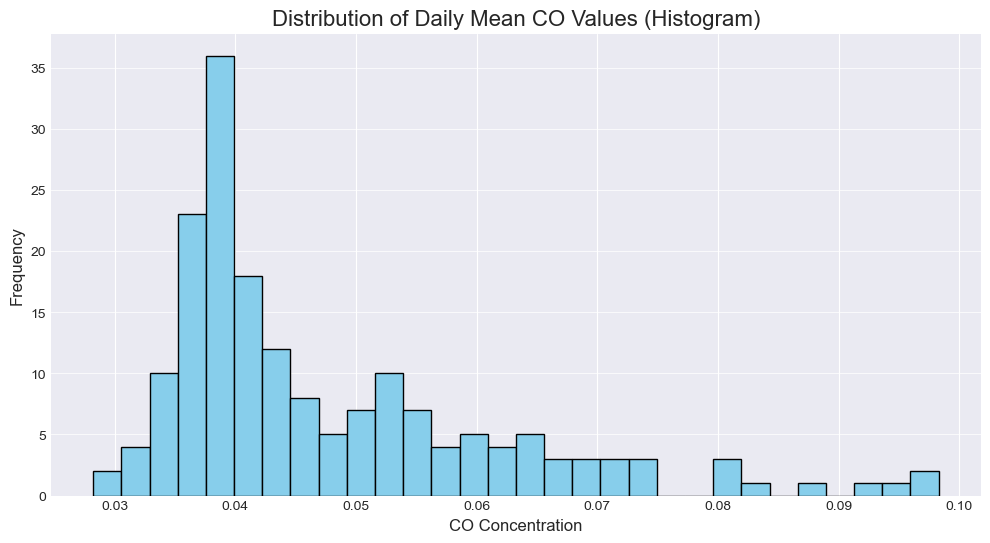

✅ Added Fourier features (YearSin, YearCos) for seasonality.


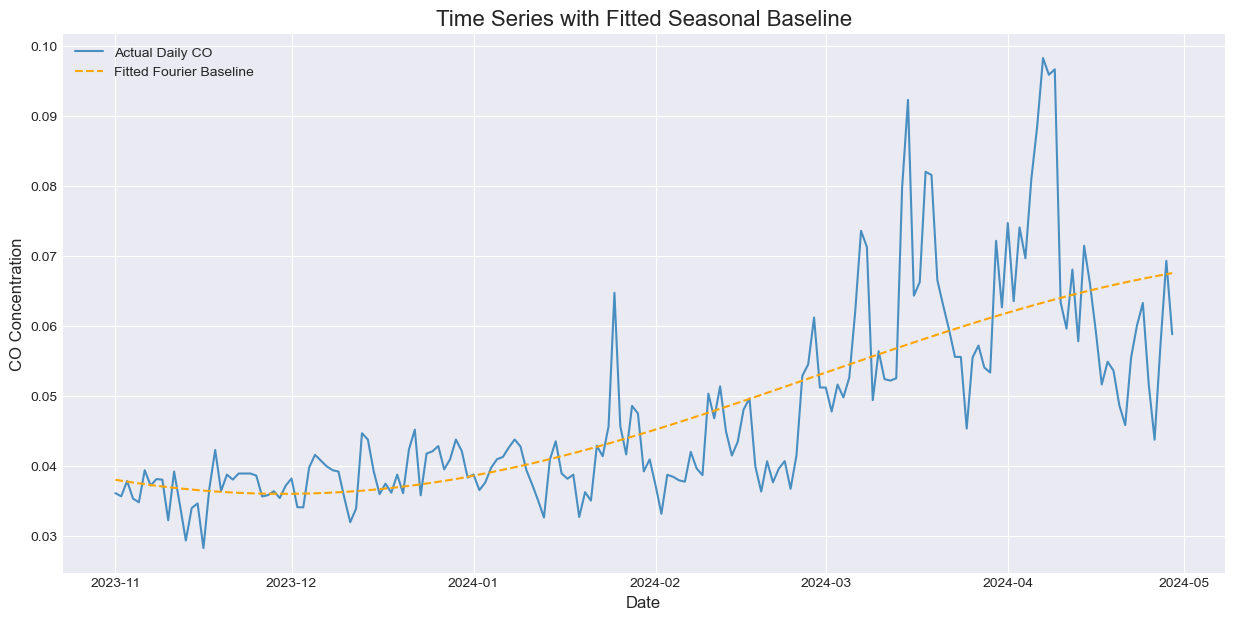

📊 Training data shape: (120, 30, 3)
📊 Testing data shape: (30, 30, 3)


/Users/sakdahomhuan/miniforge3/envs/udfire/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 30, 50)         │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,051 (121.29 KB)

 Trainable params: 31,051 (121.29 KB)

 Non-trainable params: 0 (0.00 B)


🧠 Starting model training...
Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0341 - r2_keras: -107.6766 - val_loss: 0.1327 - val_r2_keras: -100.0543
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0572 - r2_keras: -355.1936 - val_loss: 0.0966 - val_r2_keras: -72.3628
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0300 - r2_keras: -143.2371 - val_loss: 0.0960 - val_r2_keras: -69.7770
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0176 - r2_keras: -39.9176 - val_loss: 0.0766 - val_r2_keras: -54.4366
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0143 - r2_keras: -47.6234 - val_loss: 0.0504 - val_r2_keras: -34.8916
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0137 - r2_keras: -56.8067 - val_loss: 0.0433 - val_r2_keras: -29.4754
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0159 - r2_keras: -61.6750 - val_loss: 0.0449 - val_r2_keras: -30.3888
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0142

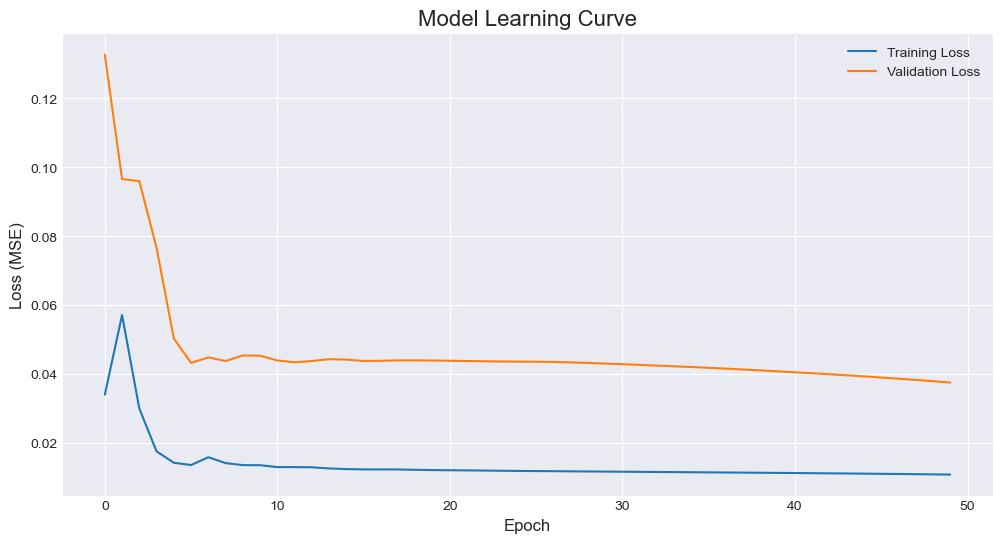

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step

--- Model Evaluation ---
📈 R-squared on Test Data: 0.0996
📉 Mean Absolute Error (MAE): 0.0112
📉 Root Mean Squared Error (RMSE): 0.0136
------------------------



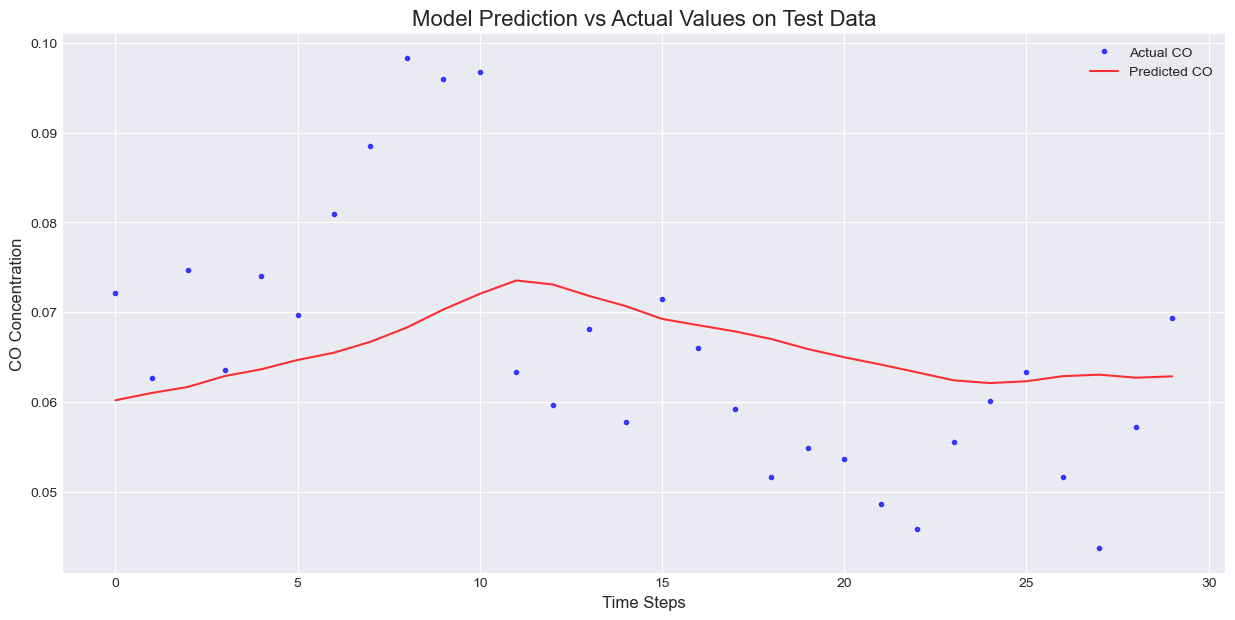

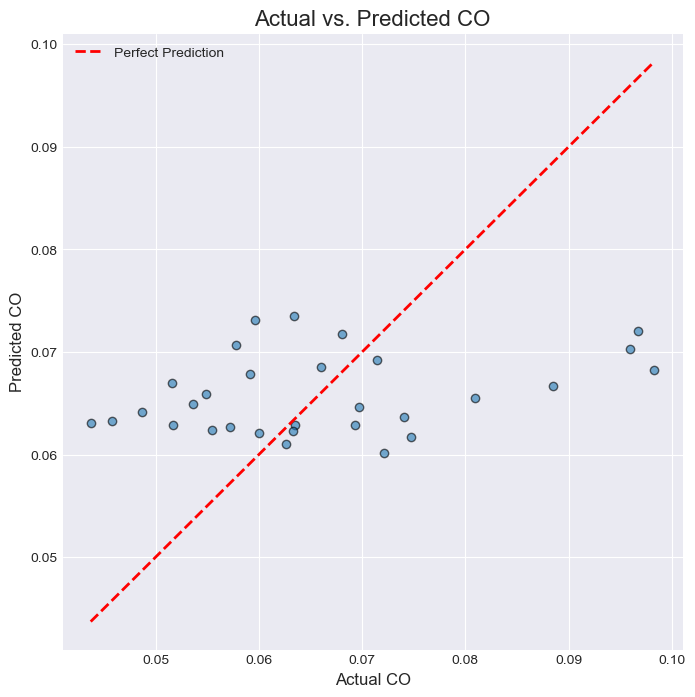

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

--- 🔮 Forecast for the Next 7 Days ---
      Date  Forecasted_CO
2024-04-30       0.064374
2024-05-01       0.065129
2024-05-02       0.065907
2024-05-03       0.066614
2024-05-04       0.067273
2024-05-05       0.067842
2024-05-06       0.068350
----------------------------------------



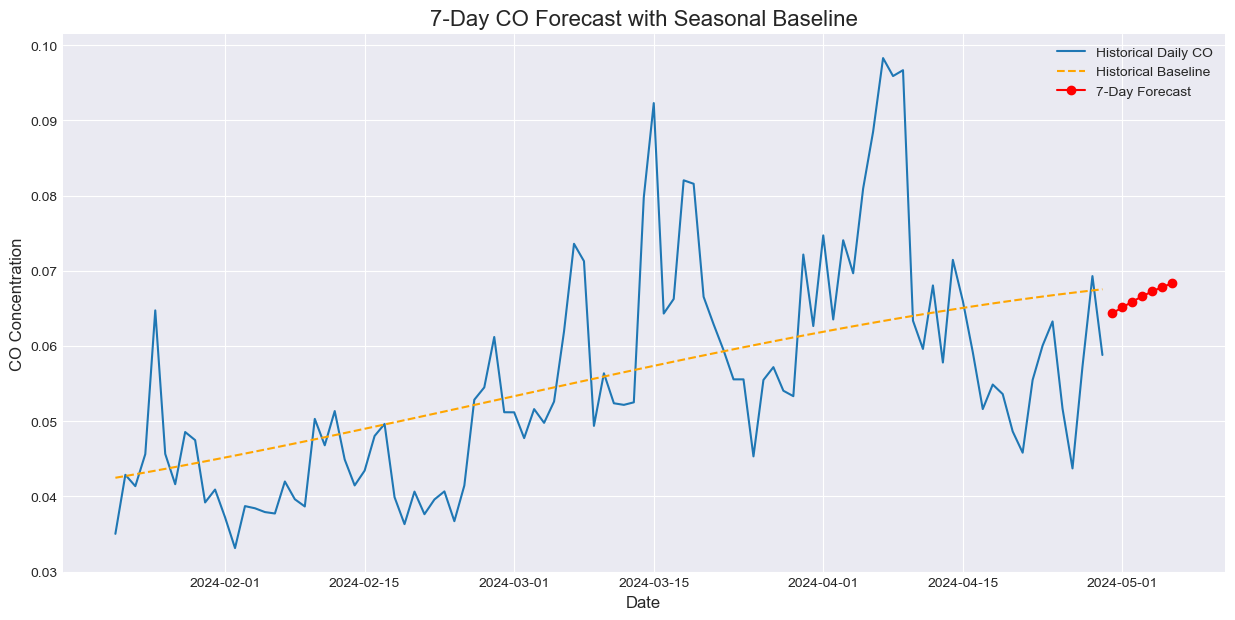

In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K

# --- 1. Load Data ---
# Load the dataset from the user-provided file path
try:
    df = pd.read_csv('CO_hex30_urban.csv')
    print("✅ Data loaded successfully.")
except FileNotFoundError:
    print("❌ Error: 'CO_hex30_urban.csv' not found. Please ensure the file is in the correct directory.")
    exit()

# --- 2. Preprocessing and Data Cleaning ---

# Convert 'date' column to datetime objects for time series analysis
df['date'] = pd.to_datetime(df['date'])

# Fix for null values: Check for nulls and fill them if any exist.
# Using forward fill is a common strategy for time series.
if df.isnull().sum().sum() > 0:
    print(f"🔎 Found {df.isnull().sum().sum()} null values. Filling them using forward fill.")
    df.fillna(method='ffill', inplace=True)
else:
    print("✅ No null values found in the dataset.")

# Group by date: Calculate the daily average CO level
# This aggregates multiple readings per day into a single representative value.
daily_co = df.groupby('date')[['CO']].mean()

# --- 3. Descriptive Statistics & Visualizations ---
print("\n--- Descriptive Statistics for Daily Average CO ---")
print(daily_co['CO'].describe())
print("--------------------------------------------------\n")

# Visualize the aggregated time series data
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(15, 7))
plt.plot(daily_co.index, daily_co['CO'], label='Daily Average CO', color='#1f77b4')
plt.title('Daily Average CO Concentration Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('CO Concentration', fontsize=12)
plt.legend()
plt.show()

# 1. Histogram of CO Values
plt.figure(figsize=(12, 6))
plt.hist(daily_co['CO'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Daily Mean CO Values (Histogram)', fontsize=16)
plt.xlabel('CO Concentration', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()


# --- 4. My Expert Method: Feature Engineering with Fourier Features ---
# To help the LSTM understand seasonality, we encode the time of year
# not as a simple number (1-365), but as a cyclical signal.
day_of_year = daily_co.index.dayofyear
daily_co['YearSin'] = np.sin(2 * np.pi * day_of_year / 365.25)
daily_co['YearCos'] = np.cos(2 * np.pi * day_of_year / 365.25)
print("✅ Added Fourier features (YearSin, YearCos) for seasonality.")

# 2. Time series with baseline
# Fit a simple linear model on the Fourier features to create a seasonal baseline
baseline_model = LinearRegression()
baseline_model.fit(daily_co[['YearSin', 'YearCos']], daily_co['CO'])
daily_co['FourierBaseline'] = baseline_model.predict(daily_co[['YearSin', 'YearCos']])

plt.figure(figsize=(15, 7))
plt.plot(daily_co.index, daily_co['CO'], label='Actual Daily CO', color='#1f77b4', alpha=0.8)
plt.plot(daily_co.index, daily_co['FourierBaseline'], label='Fitted Fourier Baseline', color='orange', linestyle='--')
plt.title('Time Series with Fitted Seasonal Baseline', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('CO Concentration', fontsize=12)
plt.legend()
plt.show()


# --- 5. Data Scaling and Sequencing ---
# We now use all three columns for scaling: CO, YearSin, YearCos
scaler = MinMaxScaler(feature_range=(0, 1))
# We drop the baseline from scaling as it was just for visualization
scaled_data = scaler.fit_transform(daily_co[['CO', 'YearSin', 'YearCos']])

# Create sequences: Use a period of past days (look_back) to predict the next day.
def create_dataset(dataset, look_back=30):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), :] # All features for 'look_back' days
        X.append(a)
        Y.append(dataset[i + look_back, 0]) # The CO value of the next day
    return np.array(X), np.array(Y)

look_back = 30 # Use 30 days of history to predict the next day.
X, y = create_dataset(scaled_data, look_back)


# --- 6. Train/Test Split ---
train_size = int(len(X) * 0.8)
X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

print(f"📊 Training data shape: {X_train.shape}")
print(f"📊 Testing data shape: {X_test.shape}")


# --- 7. Build and Train LSTM Model ---
def r2_keras(y_true, y_pred):
    SS_res = K.sum(K.square(y_true - y_pred))
    SS_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return (1 - SS_res / (SS_tot + K.epsilon()))

model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(units=50),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=[r2_keras])
model.summary()

print("\n🧠 Starting model training...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,
    shuffle=False
)
print("✅ Model training complete.")


# --- 8. Evaluation & New Visualizations ---

# 4. Learning Curve
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Learning Curve', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Make predictions on the test set
test_predict = model.predict(X_test)

# Inverse-transform the predictions and actuals
dummy_predictions = np.zeros((len(test_predict), scaled_data.shape[1]))
dummy_predictions[:, 0] = test_predict.ravel()
test_predict_inversed = scaler.inverse_transform(dummy_predictions)[:, 0]

dummy_actuals = np.zeros((len(y_test), scaled_data.shape[1]))
dummy_actuals[:, 0] = y_test.ravel()
y_test_inversed = scaler.inverse_transform(dummy_actuals)[:, 0]

# Calculate final R-squared, MAE, and RMSE scores
r2_val = r2_score(y_test_inversed, test_predict_inversed)
mae = mean_absolute_error(y_test_inversed, test_predict_inversed)
rmse = np.sqrt(mean_squared_error(y_test_inversed, test_predict_inversed))

print(f"\n--- Model Evaluation ---")
print(f"📈 R-squared on Test Data: {r2_val:.4f}")
print(f"📉 Mean Absolute Error (MAE): {mae:.4f}")
print(f"📉 Root Mean Squared Error (RMSE): {rmse:.4f}")
print("------------------------\n")

# Plot the test predictions against actual values (Time Series)
plt.figure(figsize=(15, 7))
plt.plot(y_test_inversed, label='Actual CO', color='blue', marker='.', linestyle='None', alpha=0.7)
plt.plot(test_predict_inversed, label='Predicted CO', color='red', alpha=0.8)
plt.title('Model Prediction vs Actual Values on Test Data', fontsize=16)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('CO Concentration', fontsize=12)
plt.legend()
plt.show()

# 5. Actual vs. Predicted Scatter Plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test_inversed, test_predict_inversed, alpha=0.6, edgecolor='k')
plt.plot([y_test_inversed.min(), y_test_inversed.max()], [y_test_inversed.min(), y_test_inversed.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted CO', fontsize=16)
plt.xlabel('Actual CO', fontsize=12)
plt.ylabel('Predicted CO', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


# --- 9. Predict CO for the next 7 days ---
last_sequence = scaled_data[-look_back:]
current_batch = last_sequence.reshape(1, look_back, scaled_data.shape[1])
future_predictions = []

for i in range(7):
    current_pred = model.predict(current_batch)[0]
    future_predictions.append(current_pred)
    last_date = daily_co.index[-1]
    next_date = last_date + pd.Timedelta(days=i + 1)
    next_day_of_year = next_date.dayofyear
    next_year_sin = np.sin(2 * np.pi * next_day_of_year / 365.25)
    next_year_cos = np.cos(2 * np.pi * next_day_of_year / 365.25)
    
    # We use the scaler's parameters to scale the new features manually
    # Scaled Value = (Value - Min) / (Max - Min)
    # Since scaler.scale_ = 1 / (Max - Min) and scaler.min_ = Min / (Max - Min)
    # A simpler way is to use the direct formula based on the scaler object
    sin_scaled = (next_year_sin - scaler.data_min_[1]) / (scaler.data_max_[1] - scaler.data_min_[1])
    cos_scaled = (next_year_cos - scaler.data_min_[2]) / (scaler.data_max_[2] - scaler.data_min_[2])

    new_row = np.array([[current_pred[0], sin_scaled, cos_scaled]])
    current_batch = np.append(current_batch[:, 1:, :], [new_row], axis=1)

dummy_forecast = np.zeros((len(future_predictions), scaled_data.shape[1]))
dummy_forecast[:, 0] = np.array(future_predictions).ravel()
forecast = scaler.inverse_transform(dummy_forecast)[:, 0]

forecast_dates = pd.date_range(start=daily_co.index[-1] + pd.Timedelta(days=1), periods=7)
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecasted_CO': forecast})

print("\n--- 🔮 Forecast for the Next 7 Days ---")
print(forecast_df.to_string(index=False))
print("----------------------------------------\n")

# 3. 7-Day Forecast Plot (Enhanced)
plt.figure(figsize=(15, 7))
# Plot historical data and baseline
plt.plot(daily_co.index[-100:], daily_co['CO'][-100:], label='Historical Daily CO')
plt.plot(daily_co.index[-100:], daily_co['FourierBaseline'][-100:], label='Historical Baseline', color='orange', linestyle='--')
# Plot the forecast
plt.plot(forecast_df['Date'], forecast_df['Forecasted_CO'], label='7-Day Forecast', color='red', marker='o')
plt.title('7-Day CO Forecast with Seasonal Baseline', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('CO Concentration', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

